2d-trajectories-all-A.pdf:


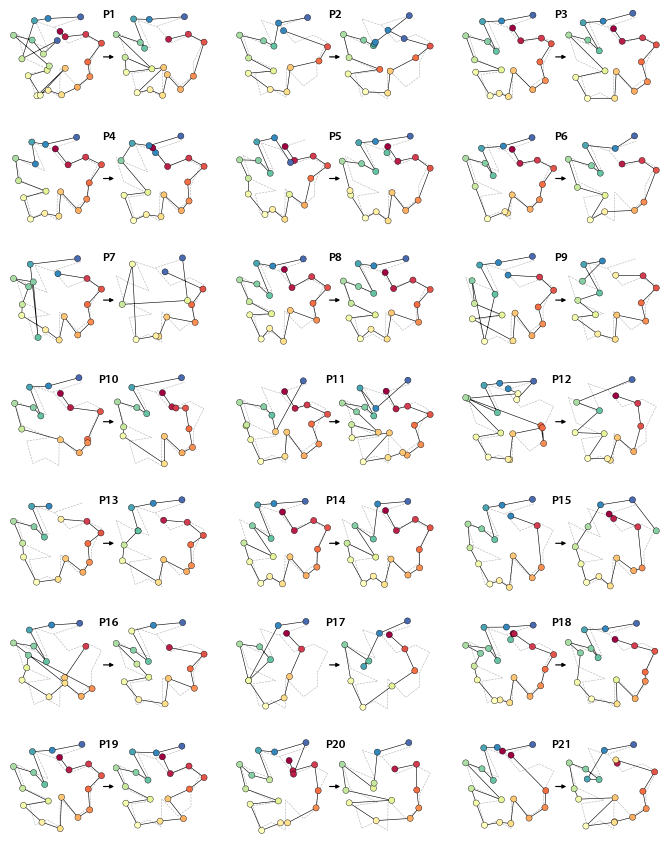

2d-trajectories-all-B.pdf:


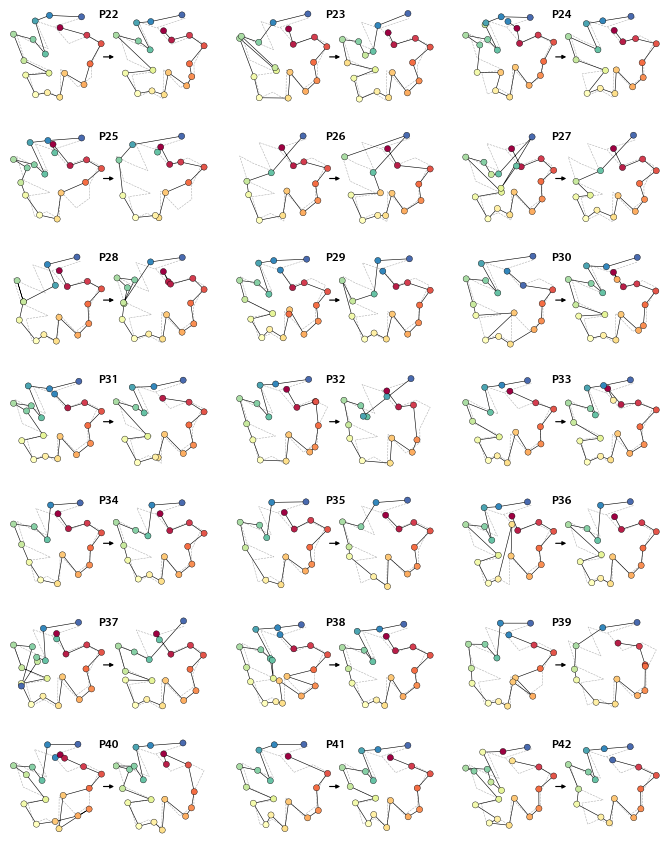

2d-trajectories-all-C.pdf:


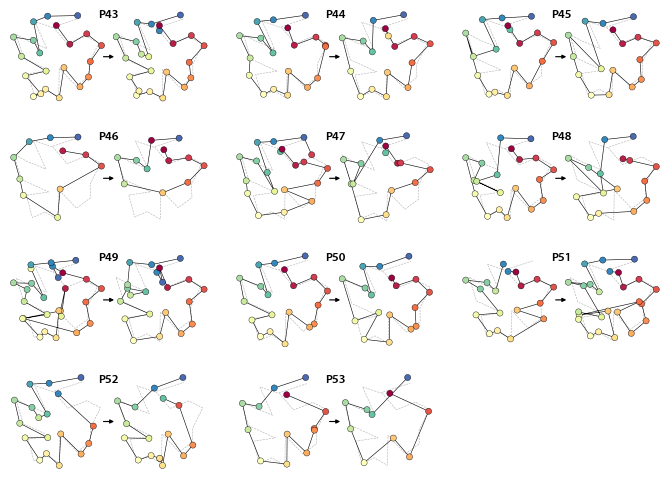

In [4]:
# IMPORTS
import math
import pickle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

from analysis_helpers.constants import FIG_DIR


# FUNCTIONS/CLASSES
def add_arrows(axes, x, y, aspace=1.5, head_width=None, arrow_length=None,
               **kwargs):
    # aspace sets the spacing between arrows; head_width and arrow_length set
    # the arrow size independently (defaulting to the original aspace-derived
    # values so behavior is unchanged unless they're passed explicitly).
    if head_width is None:
        head_width = aspace / 3
    if arrow_length is None:
        arrow_length = aspace / 10

    # distance spanned between pairs of points
    r = [0]
    for i in range(1, len(x)):
        dx = x[i] - x[i - 1]
        dy = y[i] - y[i - 1]
        r.append(np.sqrt(dx * dx + dy * dy))

    r = np.array(r)
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())
    arrow_data = []
    arrow_pos = 0
    rcount = 1
    while arrow_pos < r.sum():
        x1, x2 = x[rcount - 1], x[rcount]
        y1, y2 = y[rcount - 1], y[rcount]
        da = arrow_pos - rtot[rcount]
        theta = np.arctan2((x2 - x1), (y2 - y1))
        ax = np.sin(theta) * da + x1
        ay = np.cos(theta) * da + y1
        arrow_data.append((ax, ay, theta))
        arrow_pos += aspace
        while arrow_pos > rtot[rcount + 1]:
            rcount += 1
            if arrow_pos > rtot[-1]:
                break

    for ax, ay, theta in arrow_data:
        axes.arrow(ax,
                   ay,
                   np.sin(theta) * arrow_length,
                   np.cos(theta) * arrow_length,
                   head_width=head_width,
                   **kwargs)


# LOAD DATA
with open('trajs_2d_data.pkl', 'rb') as f:
    trajs_2d = pickle.load(f)

# CONSTANTS
# shared
EVENT_CMAP = plt.cm.Spectral
CONNECTION_LINE_COLOR = 'k'

# When True, each recall panel is framed to fit its own recall path together
# with the episode path drawn beneath it (the underlay). When False, panels use
# the shared fixed limits. Equal aspect is kept either way (no distortion).
FIT_TO_PATH = True

# panel size, and how element sizes scale relative to the main figure (whose
# recall style -- marker size 250 etc. -- is tuned for ~3.4 in panels). Every
# point-based size below (markers, linewidths, the pair arrow) scales with this.
GRID_PANEL_IN = 0.95     # side length of one recall panel (inches)
MAIN_PANEL_IN = 3.4
GRID_SCALE = GRID_PANEL_IN / MAIN_PANEL_IN

# path direction arrows along the connecting line (disabled below, kept for parity)
ARROW_COLOR = 'k'
ARROW_ALPHA = 1
ARROW_ASPACE = 3
ARROW_HEAD_WIDTH = 1
ARROW_LENGTH = 0.42

# arrow drawn in the gap between each participant's immediate and delayed panels,
# sized proportionally to the panels (scaled from the main figure) so it matches
# the rest of the grid instead of being fixed in absolute points
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3 * GRID_SCALE      # scaled from the main figure (~0.84)
PAIR_ARROW_HEAD_SCALE = 20 * GRID_SCALE    # arrowhead size, points (~5.6)
PAIR_ARROW_LENGTH = 0.17                    # arrow length in panel widths (matches main)

# recall path style (base sizes, at MAIN_PANEL_IN; scaled by GRID_SCALE below)
RECALL_EVENT_MARKERSIZE = 250
RECALL_EVENT_BORDER_LINEWIDTH = 1
RECALL_EVENT_BORDER_COLOR = 'k'
RECALL_CONNECTION_LINEWIDTH = 1.5
RECALL_EPISODE_UNDERLAY_COLOR = 'k'
RECALL_EPISODE_UNDERLAY_ALPHA = 0.3
RECALL_EPISODE_UNDERLAY_LINESTYLE = '--'

# --- Grid layout -------------------------------------------------------------
# All participant pairs shown in a grid, PAIRS_PER_ROW pairs (= 2x that many
# panels) per row, ROWS_PER_PAGE rows per page, paginated across as many pages
# as needed. No episode panel and no backgrounds. Everything is in units of one
# recall panel (1x1); the figure size is derived so panels stay physically
# square and the layout rescales if any gap changes.
PAIRS_PER_ROW = 3
ROWS_PER_PAGE = 7
PAIR_GAP = 0.08          # horizontal gap within an immediate+delayed pair
GROUP_GAP = 0.30         # horizontal gap between pairs
ROW_GAP = 0.28           # vertical gap above each row (holds the pair label)

AXES_TITLE_FONTSIZE = 9

# underlay linewidth scaled like the other lines
RECALL_EPISODE_UNDERLAY_LINEWIDTH = RECALL_CONNECTION_LINEWIDTH * GRID_SCALE

DATA_BOUNDS_MARGIN = 0.08  # fraction of the span added as padding when framing


# ============================== HELPERS ================================
N_EPISODE_EVENTS = trajs_2d['episode_path'].shape[0]
participants_by_id = {p[0]: p for p in trajs_2d['participant_data']}
episode_path = trajs_2d['episode_path']

# every participant, in P1..P53 order
ALL_PARTICIPANTS = sorted(participants_by_id, key=lambda s: int(s[1:]))


def match_colors(match_indices):
    """Color each event by its matched episode event's color."""
    return EVENT_CMAP(match_indices / N_EPISODE_EVENTS)


def draw_underlay(axes, path):
    """Faint dashed episode path (line only) drawn beneath a recall path."""
    axes.plot(path[:, 0], path[:, 1],
              color=RECALL_EPISODE_UNDERLAY_COLOR,
              alpha=RECALL_EPISODE_UNDERLAY_ALPHA,
              linewidth=RECALL_EPISODE_UNDERLAY_LINEWIDTH,
              linestyle=RECALL_EPISODE_UNDERLAY_LINESTYLE,
              zorder=0)


def draw_path(axes, path, colors, connection_linewidth,
              marker_size, border_linewidth, border_color):
    """Draw one trajectory: connecting line, (disabled) direction arrows, dots."""
    x, y = path[:, 0], path[:, 1]

    axes.plot(x, y, color=CONNECTION_LINE_COLOR,
              linewidth=connection_linewidth, zorder=1)

    # direction arrows along the connecting line -- disabled (matches main fig)
#     add_arrows(axes, x, y, aspace=ARROW_ASPACE, head_width=ARROW_HEAD_WIDTH,
#                arrow_length=ARROW_LENGTH, color=ARROW_COLOR, alpha=ARROW_ALPHA,
#                zorder=2, length_includes_head=False)

    axes.scatter(x, y, c=colors, s=marker_size, edgecolors=border_color,
                 linewidths=border_linewidth, zorder=3)


def style_axis(axes, xlim=None, ylim=None):
    """Equal aspect, no spines/ticks/background. Uses shared bounds by default,
    or the given (xlim, ylim) for a panel framed to its own path."""
    axes.set_xlim(*(xlim if xlim is not None else XLIM))
    axes.set_ylim(*(ylim if ylim is not None else YLIM))
    axes.set_aspect('equal')
    axes.set_facecolor('none')
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)


def framed_limits(path, box_aspect, margin=None):
    """(xlim, ylim) centered on `path`, covering it with `margin` padding and
    matching a panel of the given box_aspect (= width / height)."""
    if margin is None:
        margin = DATA_BOUNDS_MARGIN
    (xmin, ymin), (xmax, ymax) = path.min(0), path.max(0)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    xr, yr = (xmax - xmin) * (1 + margin), (ymax - ymin) * (1 + margin)
    if xr / yr > box_aspect:
        yr = xr / box_aspect
    else:
        xr = yr * box_aspect
    return (cx - xr / 2, cx + xr / 2), (cy - yr / 2, cy + yr / 2)


def panel_style(scale):
    """Point-based sizes for a panel `scale`x the linear size of the base recall
    panel. Marker area scales with scale**2; linewidths scale with scale."""
    return dict(
        marker_size=RECALL_EVENT_MARKERSIZE * scale ** 2,
        border_linewidth=RECALL_EVENT_BORDER_LINEWIDTH * scale,
        connection_linewidth=RECALL_CONNECTION_LINEWIDTH * scale,
    )


def compute_shared_bounds():
    """Square window covering every participant's paths + the episode (used as
    the fallback when FIT_TO_PATH is False)."""
    paths = [episode_path]
    for sid in ALL_PARTICIPANTS:
        _, imm_path, _, del_path, _ = participants_by_id[sid]
        paths.extend([imm_path, del_path])
    stacked = np.vstack(paths)
    (xmin, ymin), (xmax, ymax) = stacked.min(0), stacked.max(0)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    half = max(xmax - xmin, ymax - ymin) / 2 * (1 + DATA_BOUNDS_MARGIN)
    return (cx - half, cx + half), (cy - half, cy + half)


XLIM, YLIM = compute_shared_bounds()

# column left-edges (panel units): [imm0, del0, imm1, del1, imm2, del2]
COL_X = []
for j in range(PAIRS_PER_ROW):
    base = j * (2 + PAIR_GAP + GROUP_GAP)
    COL_X.extend([base, base + 1 + PAIR_GAP])

# row top-edges (panel units), measured downward from the top of the figure
ROW_Y = [(r + 1) * ROW_GAP + r for r in range(ROWS_PER_PAGE)]

TOTAL_W = PAIRS_PER_ROW * (2 + PAIR_GAP) + (PAIRS_PER_ROW - 1) * GROUP_GAP
TOTAL_H = ROWS_PER_PAGE * (1 + ROW_GAP)
FIG_W = TOTAL_W * GRID_PANEL_IN
FIG_H = TOTAL_H * GRID_PANEL_IN

PER_PAGE = PAIRS_PER_ROW * ROWS_PER_PAGE
N_PAGES = math.ceil(len(ALL_PARTICIPANTS) / PER_PAGE)


def cell(x_left, y_top, w, h):
    """Panel-unit rectangle (x from the left, y downward from the top) ->
    Matplotlib [left, bottom, width, height] figure-fraction rectangle."""
    return [x_left / TOTAL_W,
            (TOTAL_H - y_top - h) / TOTAL_H,
            w / TOTAL_W,
            h / TOTAL_H]


# ============================== FIGURES ================================
lets = ('A', 'B', 'C')
for page in range(N_PAGES):
    page_ids = ALL_PARTICIPANTS[page * PER_PAGE:(page + 1) * PER_PAGE]

    fig = plt.figure(figsize=(FIG_W, FIG_H))
    fig.patch.set_alpha(0)

    pair_axes = []  # (sid, ax_immediate, ax_delayed)
    for i, sid in enumerate(page_ids):
        row, col_pair = divmod(i, PAIRS_PER_ROW)
        y = ROW_Y[row]
        ax_imm = fig.add_axes(cell(COL_X[2 * col_pair], y, 1, 1))
        ax_del = fig.add_axes(cell(COL_X[2 * col_pair + 1], y, 1, 1))
        pair_axes.append((sid, ax_imm, ax_del))

        _, imm_path, imm_match, del_path, del_match = participants_by_id[sid]
        for axes, path, match in ((ax_imm, imm_path, imm_match),
                                  (ax_del, del_path, del_match)):
            draw_underlay(axes, episode_path)
            draw_path(axes, path,
                      colors=match_colors(match),
                      border_color=RECALL_EVENT_BORDER_COLOR,
                      **panel_style(GRID_SCALE))
            if FIT_TO_PATH:
                xlim, ylim = framed_limits(np.vstack([path, episode_path]), 1.0)
                style_axis(axes, xlim=xlim, ylim=ylim)
            else:
                style_axis(axes)

    fig.canvas.draw()  # finalize axis positions before reading them

    # pair labels, centered just above each pair
    for sid, ax_imm, ax_del in pair_axes:
        box_imm = ax_imm.get_position()
        box_del = ax_del.get_position()
        center_x = (box_imm.x0 + box_del.x1) / 2
        top_y = max(box_imm.y1, box_del.y1)
        fig.text(center_x, top_y, sid, ha='center', va='top',
                 fontsize=AXES_TITLE_FONTSIZE, fontweight='semibold')

    # immediate -> delayed arrow in each pair's gap
    for sid, ax_imm, ax_del in pair_axes:
        box_imm = ax_imm.get_position()
        box_del = ax_del.get_position()
        y = (box_imm.y0 + box_imm.y1) / 2
        gap_center = (box_imm.x1 + box_del.x0) / 2
        half_len = PAIR_ARROW_LENGTH * box_imm.width / 2  # length in panel widths
        fig.add_artist(FancyArrowPatch(
            (gap_center - half_len, y), (gap_center + half_len, y),
            transform=fig.transFigure, arrowstyle='-|>',
            mutation_scale=PAIR_ARROW_HEAD_SCALE, linewidth=PAIR_ARROW_LINEWIDTH,
            color=PAIR_ARROW_COLOR, clip_on=False))

#     plt.savefig(FIG_DIR / f'2d-trajectories-all-{lets[page]}.pdf', bbox_inches='tight')
    print(f'2d-trajectories-all-{lets[page]}.pdf:')
    plt.show()